In [3]:
from PYME.IO.image import ImageStack
from double_helix.DoubleGaussFit import Detector as new_detector
from detector import Detector as old_detector
import matplotlib.pyplot as plt
from scipy import ndimage
# %matplotlib widget
# plt.set_loglevel("warning")
import numpy as np
import os
from PYME.recipes.processing import BackgroundSubtractionMovingPercentile
from PYME.IO.image import ImageStack
from PYME.localization.remFitBuf import fitTask
import scipy

DEBUG:PYME.IO.DataSources.TiffDataSource:sh = {'Z': 61, 'T': 1, 'C': 1, 'Y': 66, 'X': 60}
DEBUG:PYME.IO.DataSources.TiffDataSource:raw TIFF axisOrder = XYZTC
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x0000023FBCE687C8>


filename == C:\Users\Administrator\PYMEData\PYME_DH_Detection_Testing\Yuya_Data\PYME_DH1_test\DH1_Calibration.tif
C:\Users\Administrator\PYMEData\PYME_DH_Detection_Testing\Yuya_Data\PYME_DH1_test\DH1_Calibration.tif
(61, 66, 60)
[66, 60, 61, 1, 1]


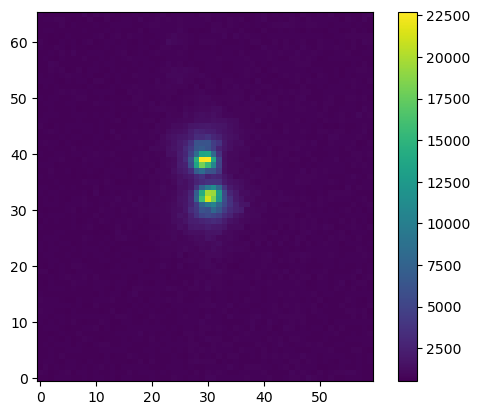

In [5]:
im = ImageStack(filename = "C:/Users/Administrator/PYMEData/PYME_DH_Detection_Testing/Yuya_Data/PYME_DH1_test/DH1_Calibration.tif", haveGUI=False)
im.mdh['Camera.ADOffset'] = 110 # [ADU]
im.mdh['voxelsize.x'] = 0.159 # [um]
im.mdh['voxelsize.y'] = 0.159 # [um]
im.mdh['Camera']['ADOffset']=475
im.mdh['Camera']['ElectronsPerCount']=4.4052
im.mdh['Camera']['NoiseFactor']=1.4
im.mdh['Camera']['ReadNoise']=90
im.mdh['Camera']['TrueEMGain']=182

dh_stack=np.squeeze(im.data_xytc[:,:,:,0]) 
dh = dh_stack[:,:,27]

plt.figure()
plt.imshow(dh, origin="lower")
plt.colorbar()
plt.show()

In [50]:
new = new_detector(roi_half_size=10, l_initial=1100, lobe_sigma_initial=250, filter_sigma=8, px_size_nm=159)
old = old_detector(im.data_xytc.shape[:2], 10, mag=0.15)

Optimization terminated successfully.
         Current function value: -0.019934
         Iterations: 15
         Function evaluations: 30


In [51]:
roiHalfSize = 10 # [pixels]

xx = np.mgrid[(-roiHalfSize):(roiHalfSize + 1)]
yy = np.mgrid[(-roiHalfSize):(roiHalfSize + 1)]


X, Y = xx[:, None], yy[None, :]



In [52]:
old_g2a_xy = ndimage.convolve(dh, old.g2a)
old_g2b_xy = ndimage.convolve(dh, old.g2b)
old_g2c_xy = ndimage.convolve(dh, old.g2c)

old_h2a_xy = ndimage.convolve(dh, old.h2a)
old_h2b_xy = ndimage.convolve(dh, old.h2b)
old_h2c_xy = ndimage.convolve(dh, old.h2c)
old_h2d_xy = ndimage.convolve(dh, old.h2d)

new_g2a_xy = ndimage.convolve(dh, new.g2a)
new_g2b_xy = ndimage.convolve(dh, new.g2b)
new_g2c_xy = ndimage.convolve(dh, new.g2c)

new_h2a_xy = ndimage.convolve(dh, new.h2a)
new_h2b_xy = ndimage.convolve(dh, new.h2b)
new_h2c_xy = ndimage.convolve(dh, new.h2c)
new_h2d_xy = ndimage.convolve(dh, new.h2d)

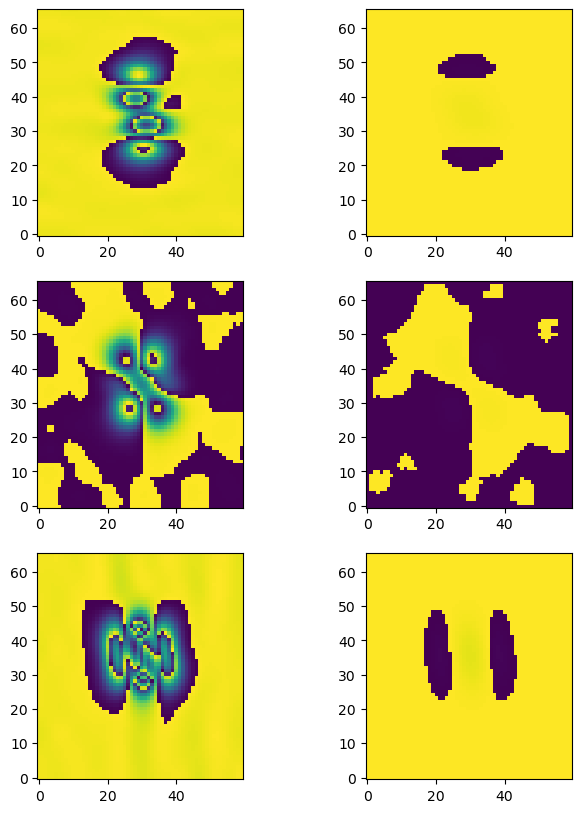

In [47]:
fig = plt.figure(figsize=(12, 10))
gspec = fig.add_gridspec(nrows=3, ncols=3)
ax1 = fig.add_subplot(gspec[0, 0])
ax2 = fig.add_subplot(gspec[1, 0])
ax3 = fig.add_subplot(gspec[2, 0])
ax4 = fig.add_subplot(gspec[0, 1])
ax5 = fig.add_subplot(gspec[1, 1])
ax6 = fig.add_subplot(gspec[2, 1])

ax1.imshow(old_g2a_xy, origin="lower")
ax2.imshow(old_g2b_xy, origin="lower")
ax3.imshow(old_g2c_xy, origin="lower")

ax4.imshow(new_g2a_xy, origin="lower")
ax5.imshow(new_g2b_xy, origin="lower")
ax6.imshow(new_g2c_xy, origin="lower")

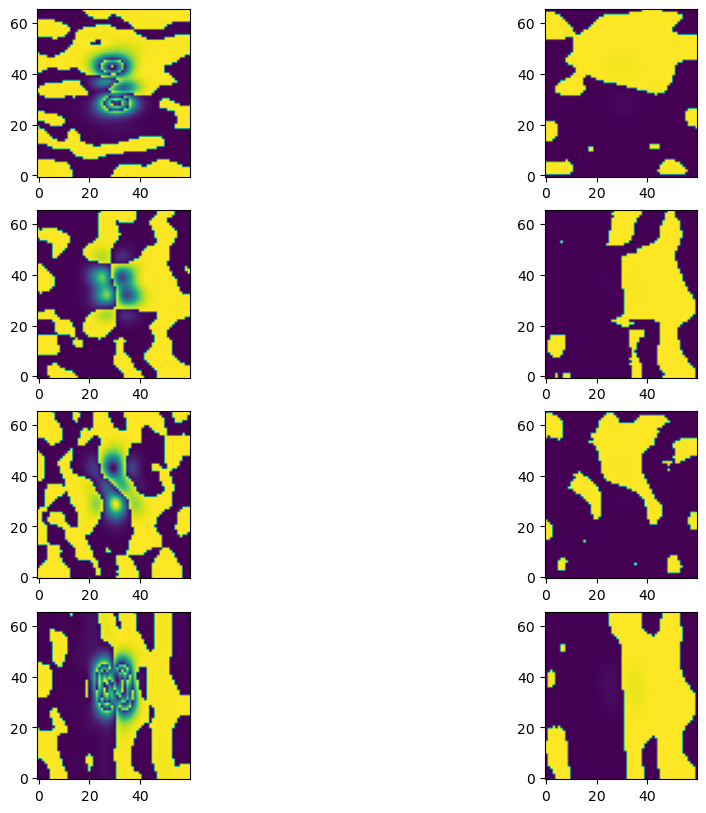

In [49]:
fig = plt.figure(figsize=(12, 10))
gspec = fig.add_gridspec(nrows=4, ncols=2)
ax1 = fig.add_subplot(gspec[0, 0])
ax2 = fig.add_subplot(gspec[1, 0])
ax3 = fig.add_subplot(gspec[2, 0])
ax4 = fig.add_subplot(gspec[3, 0])
ax5 = fig.add_subplot(gspec[0, 1])
ax6 = fig.add_subplot(gspec[1, 1])
ax7 = fig.add_subplot(gspec[2, 1])
ax8 = fig.add_subplot(gspec[3, 1])

ax1.imshow(old_h2a_xy, origin="lower")
ax2.imshow(old_h2b_xy, origin="lower")
ax3.imshow(old_h2c_xy, origin="lower")
ax4.imshow(old_h2d_xy, origin="lower")

ax5.imshow(new_h2a_xy, origin="lower")
ax6.imshow(new_h2b_xy, origin="lower")
ax7.imshow(new_h2c_xy, origin="lower")
ax8.imshow(new_h2d_xy, origin="lower")

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x0000023FBE5BBCC8>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x0000023FBE8E8C48>


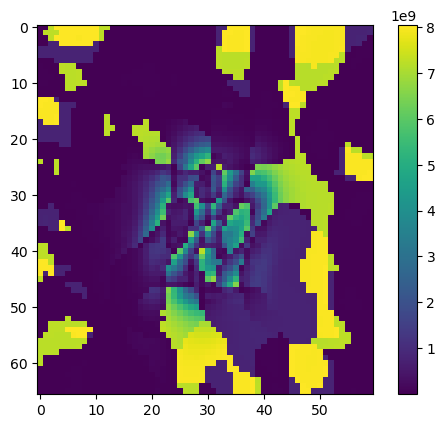

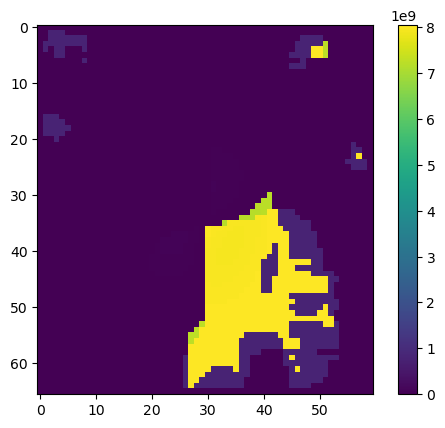

In [11]:
old_strength_image, old_angle_image = old.filter_frame(dh)

plt.figure()
plt.imshow(old_strength_image)
plt.colorbar()

new_strength_image, new_angle_image = new.filter_frame(dh)

plt.figure()
plt.imshow(new_strength_image)
plt.colorbar()

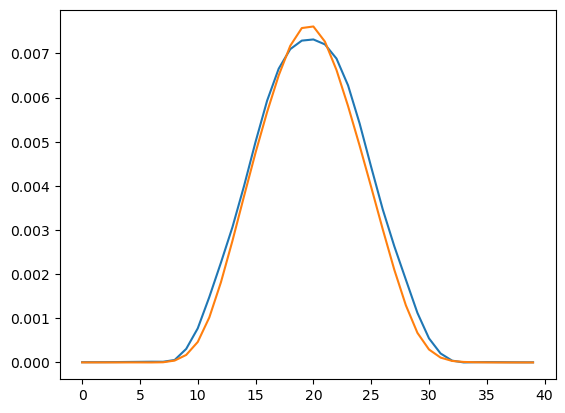

In [9]:
plt.figure()
plt.plot(range(0,40,1), old_strength_image[:,20]/np.sum(old_strength_image));
plt.plot(range(0,40,1), new_strength_image[:,20]/np.sum(new_strength_image));

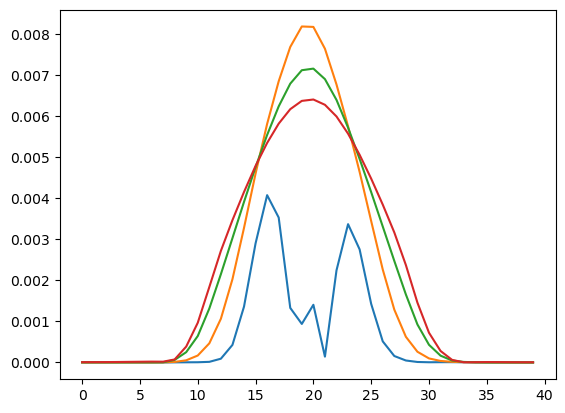

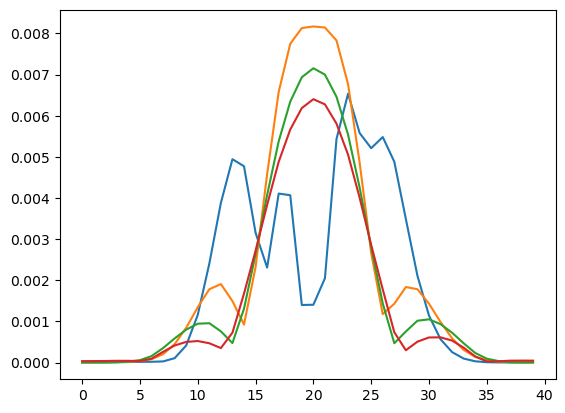

In [10]:
new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=2, pxSize=122.4)
new_strength_image_2, new_angle_image_2 = new.filter_frame(dh)

new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=3, pxSize=122.4)
new_strength_image_3, new_angle_image_3 = new.filter_frame(dh)

new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=4, pxSize=122.4)
new_strength_image_4, new_angle_image_4 = new.filter_frame(dh)

new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=5, pxSize=122.4)
new_strength_image_5, new_angle_image_5 = new.filter_frame(dh)

new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=7, pxSize=122.4)
new_strength_image_7, new_angle_image_7 = new.filter_frame(dh)

new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=9, pxSize=122.4)
new_strength_image_9, new_angle_image_9 = new.filter_frame(dh)

new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=12, pxSize=122.4)
new_strength_image_12, new_angle_image_12 = new.filter_frame(dh)

plt.figure()
plt.plot(range(0,40,1), new_strength_image_2[:,20]/np.sum(new_strength_image_2));
plt.plot(range(0,40,1), new_strength_image_3[:,20]/np.sum(new_strength_image_3));
plt.plot(range(0,40,1), new_strength_image_4[:,20]/np.sum(new_strength_image_4));
plt.plot(range(0,40,1), new_strength_image_5[:,20]/np.sum(new_strength_image_5));


plt.figure()
plt.plot(range(0,40,1), new_strength_image_2[20,:]/np.sum(new_strength_image_2));
plt.plot(range(0,40,1), new_strength_image_3[20,:]/np.sum(new_strength_image_3));
plt.plot(range(0,40,1), new_strength_image_4[20,:]/np.sum(new_strength_image_4));
plt.plot(range(0,40,1), new_strength_image_5[20,:]/np.sum(new_strength_image_5));

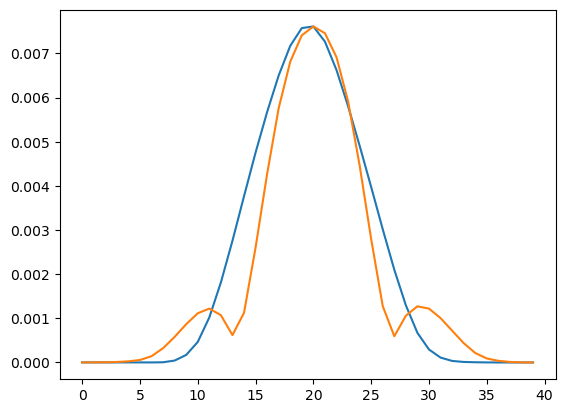

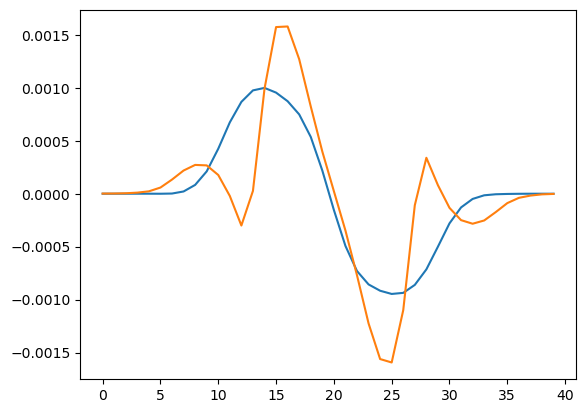

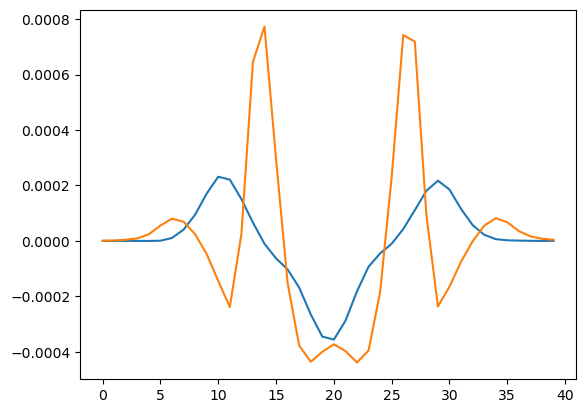

In [11]:
new = new_detector(roi_half_size=10, l_initial=854, lobe_sigma_initial=186, filter_sigma=3.63, pxSize=122.4)
new_strength_image, new_angle_image = new.filter_frame(dh)

plt.figure()
plt.plot(range(0,40,1), new_strength_image[:,20]/np.sum(new_strength_image));
plt.plot(range(0,40,1), new_strength_image[20,:]/np.sum(new_strength_image));

plt.figure()
plt.plot(range(0,40,1), np.gradient(new_strength_image[:,20]/np.sum(new_strength_image)));
plt.plot(range(0,40,1), np.gradient(new_strength_image[20,:]/np.sum(new_strength_image)));

plt.figure()
plt.plot(range(0,40,1), np.gradient(np.gradient(new_strength_image[:,20]/np.sum(new_strength_image))));
plt.plot(range(0,40,1), np.gradient(np.gradient(new_strength_image[20,:]/np.sum(new_strength_image))));

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E99AEDC8>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E9A4A648>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E9B21D88>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E7EB6188>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E98C5E48>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E9880908>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x00000223E86CC208>


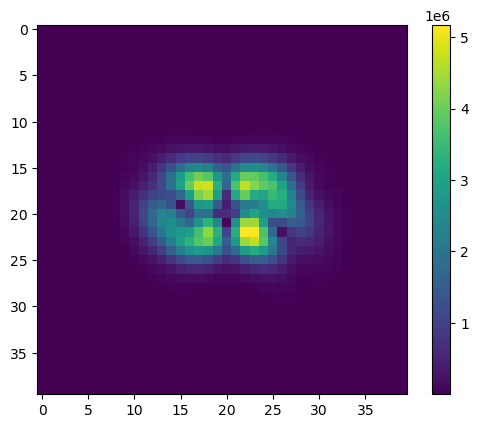

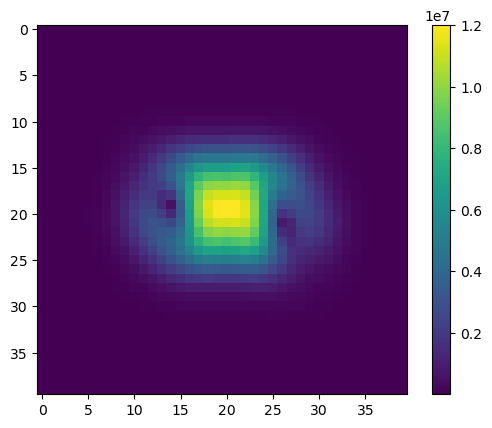

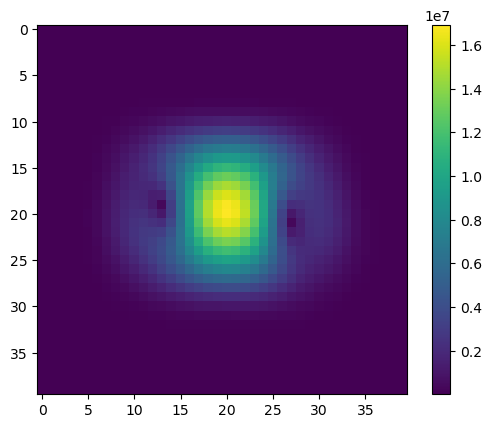

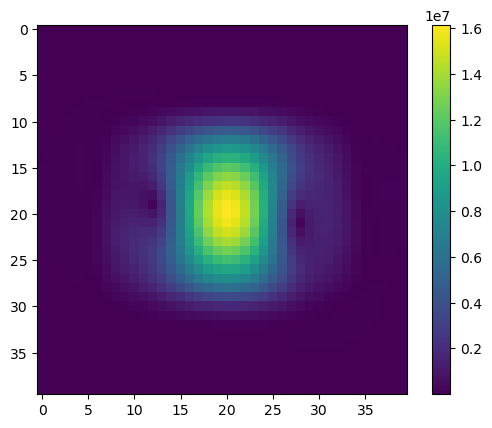

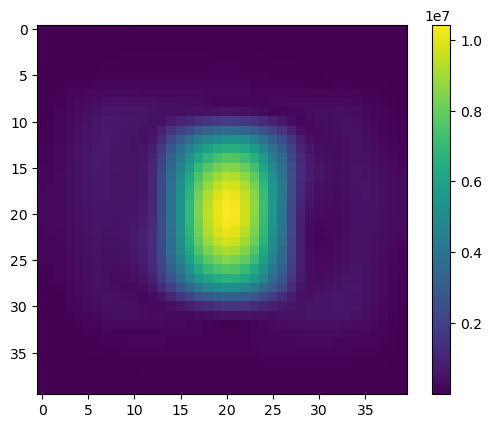

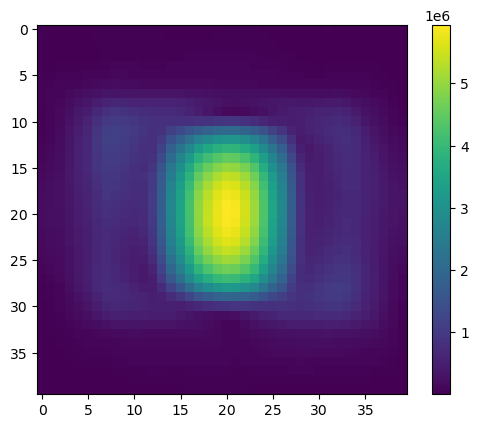

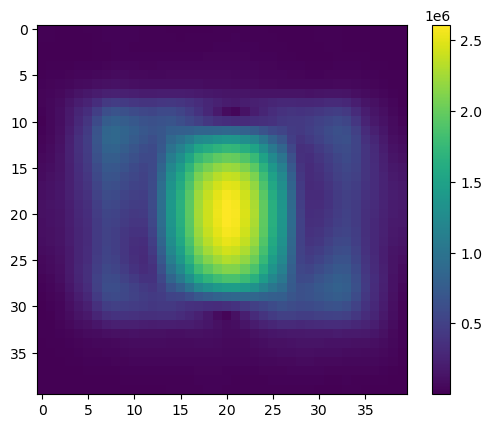

In [12]:
plt.figure()
plt.imshow(new_strength_image_2)
plt.colorbar()

plt.figure()
plt.imshow(new_strength_image_3)
plt.colorbar()

plt.figure()
plt.imshow(new_strength_image_4)
plt.colorbar()

plt.figure()
plt.imshow(new_strength_image_5)
plt.colorbar()

plt.figure()
plt.imshow(new_strength_image_7)
plt.colorbar()

plt.figure()
plt.imshow(new_strength_image_9)
plt.colorbar()

plt.figure()
plt.imshow(new_strength_image_12)
plt.colorbar()